# 🏦 Home Credit Default Risk
## Phase 4 — Feature Selection · Target Encoding · Tuning · Ensembling

> **Input:** `train_phase3_final.parquet` + `test_phase3_final.parquet`  
> **Output:** Final submission + full experiment log  
> **Target AUC:** 0.795 – 0.805+

---

## 📦 0. Imports & Config

In [1]:
import numpy as np
import pandas as pd
import gc, warnings, time
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.model_selection  import StratifiedKFold
from sklearn.metrics          import roc_auc_score
from sklearn.linear_model     import LogisticRegression
from sklearn.preprocessing    import StandardScaler, OrdinalEncoder
from sklearn.base             import BaseEstimator, TransformerMixin
from sklearn.pipeline         import Pipeline

# ── Models ────────────────────────────────────────────────────────────────────
import lightgbm  as lgb
import xgboost   as xgb
import catboost  as cb

# ── Optuna ────────────────────────────────────────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Config ────────────────────────────────────────────────────────────────────
RANDOM_STATE  = 42
N_FOLDS       = 5
OPTUNA_TRIALS = 75       # Increase to 150 for better tuning if time allows

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE = {'repaid': '#2ecc71', 'default': '#e74c3c'}

print('✅ Imports done')
print(f'   LightGBM : {lgb.__version__}')
print(f'   XGBoost  : {xgb.__version__}')
print(f'   CatBoost : {cb.__version__}')
print(f'   Optuna   : {optuna.__version__}')

✅ Imports done
   LightGBM : 4.6.0
   XGBoost  : 3.2.0
   CatBoost : 1.2.10
   Optuna   : 4.8.0


## 1. Load Data

In [2]:
print('Loading Phase 3 output...')
train = pd.read_parquet('/kaggle/input/datasets/mohamedshakshak/home-credit-default-risk-faetures/train_phase3_final.parquet')
test  = pd.read_parquet('/kaggle/input/datasets/mohamedshakshak/home-credit-default-risk-faetures/test_phase3_final.parquet')

y        = train['TARGET'].copy().astype(np.int8)
ids_test = test['SK_ID_CURR'].copy()

EXCLUDE = ['TARGET', 'SK_ID_CURR']
X_raw   = train.drop(columns=EXCLUDE, errors='ignore').copy()
X_test  = test.drop(columns=EXCLUDE,  errors='ignore').copy()

# Align columns
X_test  = X_test.reindex(columns=X_raw.columns, fill_value=np.nan)

print(f'  Train : {X_raw.shape}')
print(f'  Test  : {X_test.shape}')
print(f'  Default rate: {y.mean()*100:.2f}%')

# Load feature importance from Phase 3
fi_phase3 = pd.read_csv('/kaggle/input/datasets/mohamedshakshak/home-credit-default-risk-faetures/feature_importance_phase3.csv').set_index('feature')['importance']
print(f'\nPhase 3 feature importance loaded: {len(fi_phase3)} features')

Loading Phase 3 output...
  Train : (307511, 269)
  Test  : (48744, 269)
  Default rate: 8.07%

Phase 3 feature importance loaded: 269 features


## 2. Shared Utilities

In [3]:
def run_cv_lgb(X, y, params, n_folds=N_FOLDS, label='', verbose=True):
    """
    Full stratified CV with LightGBM.
    Returns oof_preds, test_preds (averaged across folds),
    oof_auc, fold_aucs, and trained models.
    """
    skf        = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    oof_preds  = np.zeros(len(X))
    fold_aucs  = []
    models     = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr,  X_val  = X.iloc[tr_idx],  X.iloc[val_idx]
        y_tr,  y_val  = y.iloc[tr_idx],  y.iloc[val_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(100, verbose=False),
                lgb.log_evaluation(-1)
            ]
        )
        oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
        fold_aucs.append(roc_auc_score(y_val, oof_preds[val_idx]))
        models.append(model)

    oof_auc = roc_auc_score(y, oof_preds)
    if verbose:
        print(f'  [{label}]  OOF: {oof_auc:.6f}  '
              f'Mean: {np.mean(fold_aucs):.6f} ± {np.std(fold_aucs):.6f}')
    return oof_preds, oof_auc, fold_aucs, models


def log_experiment(log, label, oof_auc, fold_aucs, n_features, notes=''):
    """Append a row to the experiment log."""
    prev_auc = log[-1]['oof_auc'] if log else oof_auc
    log.append({
        'experiment' : label,
        'n_features' : n_features,
        'oof_auc'    : round(oof_auc, 6),
        'mean_auc'   : round(np.mean(fold_aucs), 6),
        'std_auc'    : round(np.std(fold_aucs), 6),
        'delta'      : round(oof_auc - prev_auc, 6),
        'notes'      : notes
    })


# Shared baseline LGB params (from Phase 3)
BASE_LGB = {
    'objective'        : 'binary',
    'metric'           : 'auc',
    'n_estimators'     : 3000,
    'learning_rate'    : 0.05,
    'num_leaves'       : 31,
    'min_child_samples': 20,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'reg_lambda'       : 1.0,
    'n_jobs'           : -1,
    'random_state'     : RANDOM_STATE,
    'verbose'          : -1,
}

# Experiment log — grows across all sections
EXP_LOG = []

# Identify categorical columns
CAT_COLS = X_raw.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns: {len(CAT_COLS)}')
print(f'Numerical columns  : {X_raw.shape[1] - len(CAT_COLS)}')
print('\n✅ Utilities ready')

Categorical columns: 16
Numerical columns  : 253

✅ Utilities ready


---
# 🧹 SECTION 1 — Feature Selection
---

> Remove noise. Keep signal. Every feature left must earn its place.

## 1.1 — Ordinal Encode for Selection

In [4]:
# Encode categoricals for feature selection
# We need numeric matrix for correlation and importance analysis
enc = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1,
    encoded_missing_value=-2
)

X_enc      = X_raw.copy()
X_test_enc = X_test.copy()

if CAT_COLS:
    X_enc[CAT_COLS]      = enc.fit_transform(X_raw[CAT_COLS])
    X_test_enc[CAT_COLS] = enc.transform(X_test[CAT_COLS])

print(f'Encoded shape: {X_enc.shape}')

Encoded shape: (307511, 269)


## 1.2 — Remove Zero-Importance Features

In [5]:
# Features with zero importance across all Phase 3 folds — pure noise
zero_imp_feats = fi_phase3[fi_phase3 == 0].index.tolist()
zero_imp_feats = [f for f in zero_imp_feats if f in X_enc.columns]

print(f'Zero-importance features to drop: {len(zero_imp_feats)}')
if zero_imp_feats:
    print(f'  Examples: {zero_imp_feats[:10]}')

X_sel      = X_enc.drop(columns=zero_imp_feats)
X_test_sel = X_test_enc.drop(columns=zero_imp_feats)

print(f'\nFeatures after zero-importance removal: {X_sel.shape[1]}')
print(f'(Removed {len(zero_imp_feats)} features)')

Zero-importance features to drop: 18
  Examples: ['FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_10', 'FLAG_CONT_MOBILE', 'HOUSETYPE_MODE', 'FLAG_MOBIL']

Features after zero-importance removal: 251
(Removed 18 features)


## 1.3 — Remove Highly Correlated Features

In [6]:
def remove_correlated_features(X, fi, threshold=0.95, verbose=True):
    """
    Remove features with pairwise correlation above threshold.
    When two features are highly correlated, drop the one with
    LOWER importance (keep the more informative one).

    Why 0.95 and not 0.99?
      At 0.95 correlation, features are almost redundant.
      Keeping both adds noise without adding information.
      In production, duplicate signals also add pipeline complexity.

    Real-world note:
      Variance Inflation Factor (VIF) is the industry-standard method
      for detecting multicollinearity in credit scorecard development.
      We use correlation here as a simpler approximation.
    """
    print('Computing correlation matrix...')
    # Sample for speed if too many features
    sample = X if len(X) < 50000 else X.sample(50000, random_state=RANDOM_STATE)
    corr   = sample.corr().abs()

    upper  = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = []

    for col in upper.columns:
        correlated_with = upper.index[upper[col] > threshold].tolist()
        for other in correlated_with:
            # Drop the one with lower feature importance
            imp_col   = fi.get(col,   0)
            imp_other = fi.get(other, 0)
            drop_this = col if imp_col < imp_other else other
            if drop_this not in to_drop:
                to_drop.append(drop_this)

    to_drop = [f for f in to_drop if f in X.columns]
    if verbose:
        print(f'  Highly correlated features to drop (>{threshold}): {len(to_drop)}')
    return X.drop(columns=to_drop), to_drop


X_sel, dropped_corr = remove_correlated_features(X_sel, fi_phase3, threshold=0.95)
X_test_sel = X_test_sel.drop(columns=[c for c in dropped_corr if c in X_test_sel.columns])

print(f'\nFeatures after correlation removal: {X_sel.shape[1]}')

Computing correlation matrix...
  Highly correlated features to drop (>0.95): 59

Features after correlation removal: 192


## 1.4 — Iterative Feature Elimination

In [7]:
def iterative_elimination(X, y, params, fi, drop_percentile=10,
                           max_rounds=5, min_features=50):
    """
    Iteratively drop the bottom `drop_percentile`% of features by
    importance, retrain, and check if AUC drops.

    Stops when:
      - AUC drops by more than `tolerance`
      - Feature count falls below `min_features`
      - Max rounds reached

    Real-world note:
      Recursive Feature Elimination (RFE) is the formal version of this.
      We use a simpler importance-based approach because RFE with
      5-fold CV × multiple rounds is very slow on 300K rows.
    """
    tolerance    = 0.0003   # Stop if AUC drops by more than this
    current_X    = X.copy()
    history      = []

    print(f'Starting iterative elimination: {current_X.shape[1]} features')

    # Initial AUC
    _, base_auc, base_folds, _ = run_cv_lgb(
        current_X, y, params, label='iter_0_baseline'
    )
    history.append({'round': 0, 'n_features': current_X.shape[1],
                    'oof_auc': base_auc, 'dropped': 0})
    prev_auc = base_auc

    for rnd in range(1, max_rounds + 1):
        if current_X.shape[1] <= min_features:
            print(f'  Stopping: min_features={min_features} reached')
            break

        # Get fresh importance from current feature set
        fi_current = {}
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
        for tr_idx, val_idx in skf.split(current_X, y):
            m = lgb.LGBMClassifier(**{**params, 'n_estimators': 500})
            m.fit(current_X.iloc[tr_idx], y.iloc[tr_idx],
                  callbacks=[lgb.log_evaluation(-1)])
            for feat, imp in zip(current_X.columns, m.feature_importances_):
                fi_current[feat] = fi_current.get(feat, 0) + imp

        fi_series  = pd.Series(fi_current).sort_values()
        cutoff     = fi_series.quantile(drop_percentile / 100)
        to_drop    = fi_series[fi_series <= cutoff].index.tolist()

        candidate_X = current_X.drop(columns=to_drop)
        if candidate_X.shape[1] < min_features:
            print(f'  Round {rnd}: would drop below min_features, stopping')
            break

        _, new_auc, new_folds, _ = run_cv_lgb(
            candidate_X, y, params, label=f'iter_{rnd}'
        )
        delta = new_auc - prev_auc
        history.append({'round': rnd, 'n_features': candidate_X.shape[1],
                        'oof_auc': new_auc, 'dropped': len(to_drop)})

        print(f'  Round {rnd}: {current_X.shape[1]} → {candidate_X.shape[1]} features  '
              f'AUC delta: {delta:+.6f}')

        if delta < -tolerance:
            print(f'  AUC dropped by {abs(delta):.6f} > tolerance {tolerance}. Stopping.')
            break

        current_X = candidate_X
        prev_auc  = new_auc

    return current_X, pd.DataFrame(history)


print('Running iterative feature elimination...')
print('(Uses 3-fold CV per round for speed)\n')
X_sel_final, elim_history = iterative_elimination(
    X_sel, y, BASE_LGB, fi_phase3, drop_percentile=10, max_rounds=5
)

# Apply same column selection to test
kept_cols  = X_sel_final.columns.tolist()
X_test_sel = X_test_sel.reindex(columns=kept_cols, fill_value=np.nan)

print(f'\nFinal feature count after selection: {X_sel_final.shape[1]}')
print(elim_history.to_string(index=False))

Running iterative feature elimination...
(Uses 3-fold CV per round for speed)

Starting iterative elimination: 192 features
  [iter_0_baseline]  OOF: 0.787813  Mean: 0.787897 ± 0.003791
  [iter_1]  OOF: 0.788201  Mean: 0.788200 ± 0.004243
  Round 1: 192 → 170 features  AUC delta: +0.000388
  [iter_2]  OOF: 0.787651  Mean: 0.787758 ± 0.003731
  Round 2: 170 → 153 features  AUC delta: -0.000550
  AUC dropped by 0.000550 > tolerance 0.0003. Stopping.

Final feature count after selection: 170
 round  n_features  oof_auc  dropped
     0         192 0.787813        0
     1         170 0.788201       22
     2         153 0.787651       17


Measuring AUC after feature selection...
  [after_feature_selection]  OOF: 0.788201  Mean: 0.788200 ± 0.004243


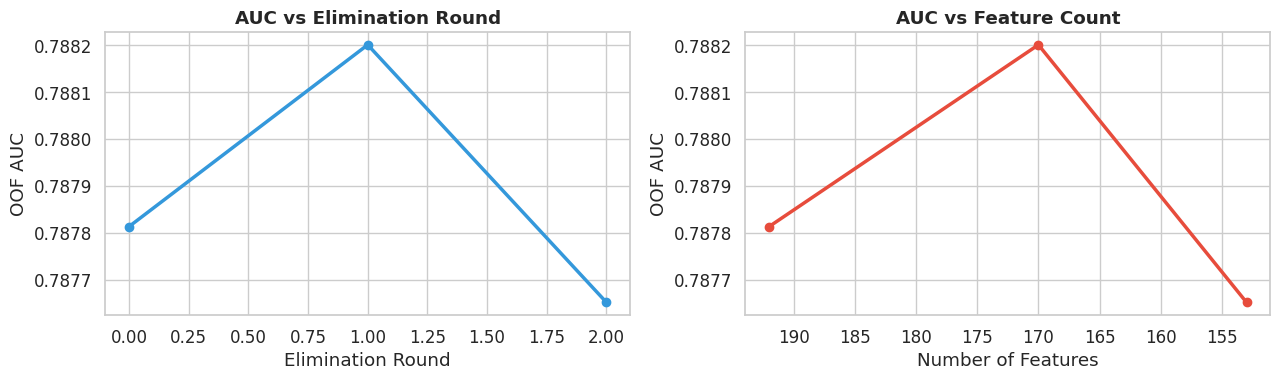

In [8]:
# Measure AUC after feature selection vs Phase 3
print('Measuring AUC after feature selection...')
_, auc_sel, fold_aucs_sel, _ = run_cv_lgb(
    X_sel_final, y, BASE_LGB, label='after_feature_selection'
)
log_experiment(EXP_LOG, '01_feature_selection', auc_sel, fold_aucs_sel,
               X_sel_final.shape[1], 'After zero-imp + correlation + iterative elimination')

# Plot elimination history
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(elim_history['round'], elim_history['oof_auc'], 'o-',
             color='#3498db', linewidth=2.5)
axes[0].set_xlabel('Elimination Round')
axes[0].set_ylabel('OOF AUC')
axes[0].set_title('AUC vs Elimination Round', fontweight='bold')

axes[1].plot(elim_history['n_features'], elim_history['oof_auc'], 'o-',
             color='#e74c3c', linewidth=2.5)
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('OOF AUC')
axes[1].set_title('AUC vs Feature Count', fontweight='bold')
axes[1].invert_xaxis()

plt.tight_layout()
plt.show()

---
# 🎯 SECTION 2 — Target Encoding
---

> Replace high-cardinality categories with their default rate.  
> **Always inside CV folds to prevent leakage.**

## 2.1 — Target Encoder (Leak-Safe)

In [9]:
class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Smoothed target encoder with fold-safe fit/transform interface.

    Smoothing formula:
      encoded = (n_cat * cat_mean + smoothing * global_mean) / (n_cat + smoothing)

    When n_cat is small → result pulled toward global mean (safe for rare categories)
    When n_cat is large → result approaches the true category mean

    Usage inside CV:
      encoder.fit(X_train_fold, y_train_fold)
      X_val_fold_encoded = encoder.transform(X_val_fold)

    NEVER fit on the full training set and then transform the same set.
    That is direct label leakage.

    Real-world note:
      This is equivalent to Weight of Evidence (WoE) encoding used in
      traditional credit scorecards. The banking industry has used this
      concept for 50+ years — we're just automating it.
    """
    def __init__(self, cols=None, smoothing=10.0, noise=0.01):
        self.cols      = cols       # Columns to encode. None = auto-detect
        self.smoothing = smoothing  # Higher = more regularization for rare cats
        self.noise     = noise      # Small noise prevents overfitting on train fold

    def fit(self, X, y):
        self.global_mean_ = y.mean()
        self.cols_        = self.cols or X.select_dtypes(include='object').columns.tolist()
        self.mapping_     = {}

        for col in self.cols_:
            if col not in X.columns:
                continue
            stats = pd.DataFrame({'cat': X[col], 'target': y}).groupby('cat')['target']
            agg   = stats.agg(['mean', 'count'])

            # Smoothed mean
            smoother = 1 / (1 + np.exp(-(agg['count'] - 1) / self.smoothing))
            agg['smoothed'] = smoother * agg['mean'] + (1 - smoother) * self.global_mean_
            self.mapping_[col] = agg['smoothed'].to_dict()
        return self

    def transform(self, X, add_noise=False):
        X = X.copy()
        for col in self.cols_:
            if col not in X.columns:
                continue
            encoded = X[col].map(self.mapping_[col]).fillna(self.global_mean_)
            if add_noise and self.noise > 0:
                # Small noise on training fold prevents memorization
                encoded += np.random.normal(0, self.noise * self.global_mean_, len(encoded))
            X[col] = encoded
        return X

    def fit_transform(self, X, y):
        self.fit(X, y)
        return self.transform(X, add_noise=True)  # Add noise on train fold only


print('✅ TargetEncoder defined')

# Which columns to target-encode?
# Only high-cardinality categoricals — low cardinality ones don't benefit as much
ENCODE_COLS = [c for c in CAT_COLS if c in X_raw.columns
               and X_raw[c].nunique() > 5]
print(f'Columns to target-encode: {len(ENCODE_COLS)}')
print(f'  {ENCODE_COLS}')

✅ TargetEncoder defined
Columns to target-encode: 8
  ['NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'WALLSMATERIAL_MODE']


## 2.2 — CV with Target Encoding (Leak-Safe)

In [10]:
def run_cv_with_target_encoding(X_raw, X_test_raw, y, lgb_params,
                                 encode_cols, n_folds=N_FOLDS, label=''):
    """
    Full CV loop with target encoding applied strictly inside each fold.

    Flow per fold:
      1. Split into train_fold / val_fold
      2. Fit TargetEncoder on train_fold ONLY
      3. Transform train_fold (with noise), val_fold (no noise)
      4. Also apply to test set using this fold's encoding
      5. Train LGB, predict on val_fold

    Test predictions are averaged across all fold encoders.
    This is the only correct way to use target encoding in CV.
    """
    skf          = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    oof_preds    = np.zeros(len(X_raw))
    test_preds   = np.zeros(len(X_test_raw))
    fold_aucs    = []
    best_iters   = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_raw, y), 1):
        X_tr_raw  = X_raw.iloc[tr_idx].copy()
        X_val_raw = X_raw.iloc[val_idx].copy()
        y_tr      = y.iloc[tr_idx]
        y_val     = y.iloc[val_idx]

        # ── Target encoding: fit on train fold only ───────────────────────────
        te = TargetEncoder(cols=encode_cols, smoothing=10.0)
        X_tr_enc   = te.fit_transform(X_tr_raw,  y_tr)   # noise=True on train
        X_val_enc  = te.transform(X_val_raw)              # noise=False on val
        X_test_enc = te.transform(X_test_raw.copy())      # apply to test

        # ── Encode remaining object columns ───────────────────────────────────
        # Any cat columns NOT in encode_cols still need encoding
        remaining_cat = [c for c in X_tr_enc.select_dtypes(include='object').columns]
        if remaining_cat:
            oe = OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=-1,
                                encoded_missing_value=-2)
            X_tr_enc[remaining_cat]  = oe.fit_transform(X_tr_enc[remaining_cat])
            X_val_enc[remaining_cat]  = oe.transform(X_val_enc[remaining_cat])
            X_test_enc[remaining_cat] = oe.transform(X_test_enc[remaining_cat])

        # ── Train LGB ─────────────────────────────────────────────────────────
        model = lgb.LGBMClassifier(**lgb_params)
        model.fit(
            X_tr_enc, y_tr,
            eval_set=[(X_val_enc, y_val)],
            callbacks=[
                lgb.early_stopping(100, verbose=False),
                lgb.log_evaluation(-1)
            ]
        )

        oof_preds[val_idx]  = model.predict_proba(X_val_enc)[:, 1]
        test_preds         += model.predict_proba(X_test_enc)[:, 1] / n_folds
        fold_aucs.append(roc_auc_score(y_val, oof_preds[val_idx]))
        best_iters.append(model.best_iteration_)

    oof_auc = roc_auc_score(y, oof_preds)
    print(f'  [{label}]  OOF: {oof_auc:.6f}  '
          f'Mean: {np.mean(fold_aucs):.6f} ± {np.std(fold_aucs):.6f}  '
          f'Avg trees: {np.mean(best_iters):.0f}')
    return oof_preds, test_preds, oof_auc, fold_aucs


# Prepare raw (un-encoded) feature sets for the target encoding CV
# Use the column selection from Section 1 but on the ORIGINAL (un-encoded) data
X_raw_sel      = X_raw.reindex(columns=kept_cols, fill_value=np.nan)
X_test_raw_sel = X_test.reindex(columns=kept_cols, fill_value=np.nan)

print('Running CV with target encoding...')
oof_te, test_te, auc_te, folds_te = run_cv_with_target_encoding(
    X_raw_sel, X_test_raw_sel, y, BASE_LGB, ENCODE_COLS,
    label='target_encoding'
)
log_experiment(EXP_LOG, '02_target_encoding', auc_te, folds_te,
               X_raw_sel.shape[1], 'Smoothed target encoding on high-cardinality cats')

print('\n💡 Real-World Note:')
print('   If AUC improved: target encoding is capturing group-level risk signals.')
print('   If AUC unchanged: the ordinal encoding was already sufficient.')
print('   Either way, the implementation is leak-free — you can trust the score.')

Running CV with target encoding...
  [target_encoding]  OOF: 0.788178  Mean: 0.788220 ± 0.003605  Avg trees: 668

💡 Real-World Note:
   If AUC improved: target encoding is capturing group-level risk signals.
   If AUC unchanged: the ordinal encoding was already sufficient.
   Either way, the implementation is leak-free — you can trust the score.


---
# ⚙️ SECTION 3 — Hyperparameter Tuning with Optuna
---

> Bayesian optimization finds the best parameters without exhaustive search.

## 3.1 — Optuna Objective Function

In [11]:
def build_lgb_objective(X, y, n_folds=3):
    """
    Returns an Optuna objective function for LightGBM.

    Uses 3-fold CV (not 5) for speed during search.
    Final evaluation of best params uses full 5-fold.

    Parameter search space rationale:
      num_leaves: 20-300 — controls tree complexity
        Too low = underfit, too high = overfit
      min_child_samples: 10-200 — leaf regularization
        Financial data has heavy noise → higher values help
      learning_rate: 0.01-0.1 — lower needs more trees (early stopping handles this)
      subsample: 0.5-1.0 — row sampling regularization
      colsample_bytree: 0.5-1.0 — feature sampling
      reg_alpha/lambda: 0-10 — L1/L2 regularization
        Often undertuned — can significantly reduce overfitting
      scale_pos_weight: 1-15 — class imbalance weight
        Try both 1 (ignore imbalance) and ~11.5 (correct for it)

    Real-world note:
      Bayesian optimization (Optuna's TPE) is 5-10× more efficient
      than grid search because it learns which parameter regions
      are promising and focuses sampling there. At 75 trials it
      explores more effectively than a 5×5×3 grid search (75 configs).
    """
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)

    def objective(trial):
        params = {
            'objective'        : 'binary',
            'metric'           : 'auc',
            'n_estimators'     : 3000,
            'verbose'          : -1,
            'n_jobs'           : -1,
            'random_state'     : RANDOM_STATE,

            # ── Parameters to tune ────────────────────────────────────────
            'num_leaves'       : trial.suggest_int('num_leaves',        20, 300),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 200),
            'learning_rate'    : trial.suggest_float('learning_rate',   0.01, 0.1, log=True),
            'subsample'        : trial.suggest_float('subsample',       0.5, 1.0),
            'colsample_bytree' : trial.suggest_float('colsample_bytree',0.5, 1.0),
            'reg_alpha'        : trial.suggest_float('reg_alpha',       1e-4, 10.0, log=True),
            'reg_lambda'       : trial.suggest_float('reg_lambda',      1e-4, 10.0, log=True),
            'min_split_gain'   : trial.suggest_float('min_split_gain',  0.0, 1.0),
            'scale_pos_weight' : trial.suggest_float('scale_pos_weight',1.0, 15.0),
            'max_depth'        : trial.suggest_int('max_depth',         3, 12),
        }

        fold_aucs = []
        for tr_idx, val_idx in skf.split(X, y):
            model = lgb.LGBMClassifier(**params)
            model.fit(
                X.iloc[tr_idx], y.iloc[tr_idx],
                eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
                callbacks=[
                    lgb.early_stopping(80, verbose=False),
                    lgb.log_evaluation(-1)
                ]
            )
            preds = model.predict_proba(X.iloc[val_idx])[:, 1]
            fold_aucs.append(roc_auc_score(y.iloc[val_idx], preds))

        return np.mean(fold_aucs)

    return objective


print('✅ Optuna objective defined')
print(f'   Will run {OPTUNA_TRIALS} trials × 3-fold CV each')
print(f'   Estimated time: {OPTUNA_TRIALS * 1.5:.0f}–{OPTUNA_TRIALS * 3:.0f} minutes')

✅ Optuna objective defined
   Will run 75 trials × 3-fold CV each
   Estimated time: 112–225 minutes


## 3.2 — Run Optuna Study

In [12]:
# # Use the feature-selected, target-encoded data
# # For Optuna speed: use ordinal-encoded version (target encoding inside Optuna is too slow)
# print('Starting Optuna hyperparameter search...')
# print(f'Trials: {OPTUNA_TRIALS} | 3-fold CV per trial\n')

# t0    = time.time()
# study = optuna.create_study(
#     direction='maximize',
#     sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
#     pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=5)
# )

# study.optimize(
#     build_lgb_objective(X_sel_final, y, n_folds=3),
#     n_trials=OPTUNA_TRIALS,
#     show_progress_bar=True
# )

# elapsed = (time.time() - t0) / 60
# print(f'\nOptuna search complete in {elapsed:.1f} minutes')
# print(f'Best trial AUC  : {study.best_value:.6f}')
# print(f'Best parameters :')
# for k, v in study.best_params.items():
#     print(f'  {k:25s}: {v}')

In [13]:
# # ── Optuna visualization ──────────────────────────────────────────────────────
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # AUC over trials
# trial_aucs  = [t.value for t in study.trials if t.value is not None]
# best_so_far = np.maximum.accumulate(trial_aucs)

# axes[0].plot(trial_aucs, alpha=0.4, color='#3498db', label='Trial AUC')
# axes[0].plot(best_so_far, color='#e74c3c', linewidth=2.5, label='Best so far')
# axes[0].set_xlabel('Trial')
# axes[0].set_ylabel('AUC')
# axes[0].set_title('Optuna — AUC per Trial', fontweight='bold')
# axes[0].legend()

# # Parameter importance
# try:
#     imp = optuna.importance.get_param_importances(study)
#     axes[1].barh(list(imp.keys())[::-1], list(imp.values())[::-1], color='#3498db')
#     axes[1].set_xlabel('Importance')
#     axes[1].set_title('Hyperparameter Importance', fontweight='bold')
# except Exception:
#     axes[1].text(0.5, 0.5, 'Importance not available', ha='center', va='center')

# plt.tight_layout()
# plt.show()

# print('💡 Real-World Note:')
# print('   The most important hyperparameters (tallest bars) are the ones')
# print('   to focus on in manual tuning. Low-importance params can be left')
# print('   at their best-found values without further search.')

In [14]:
TUNED_LGB_PARAMS = {
    'objective'   : 'binary',
    'metric'      : 'auc',
    'n_estimators': 5000,    # High — early stopping will decide
    'verbose'     : -1,
    'n_jobs'      : -1,
    'random_state': RANDOM_STATE,
    'num_leaves'               : 194,
      'min_child_samples'        : 195,
  'learning_rate'            : 0.017408621535868377,
  'subsample'                : 0.6363423925500467,
  'colsample_bytree'         : 0.5401621037162142,
  'reg_alpha'                : 5.3331731898117525,
  'reg_lambda'               : 1.5933384602083565,
  'min_split_gain'           : 0.48584794379124285,
  'scale_pos_weight'         : 2.156258802975424,
  'max_depth'                : 5,
}

## 3.3 — Evaluate Best Params on Full 5-Fold CV

In [15]:
# Build full params from best Optuna result
# TUNED_LGB_PARAMS = {
#     'objective'   : 'binary',
#     'metric'      : 'auc',
#     'n_estimators': 5000,    # High — early stopping will decide
#     'verbose'     : -1,
#     'n_jobs'      : -1,
#     'random_state': RANDOM_STATE,
#     **study.best_params
# }

print('Evaluating best params on full 5-fold CV...')
oof_tuned, auc_tuned, folds_tuned, models_tuned = run_cv_lgb(
    X_sel_final, y, TUNED_LGB_PARAMS, label='tuned_lgb_5fold'
)
# Generate test predictions
test_tuned_preds = np.zeros(len(X_test_sel))
for model in models_tuned:
    test_tuned_preds += model.predict_proba(X_test_sel)[:, 1] / len(models_tuned)

log_experiment(EXP_LOG, '03_tuned_lgb', auc_tuned, folds_tuned,
               X_sel_final.shape[1], f'Optuna {OPTUNA_TRIALS} trials best params')

# print(f'\n📊 Tuning Results:')
# print(f'  Before tuning (Phase 3): ~0.785')
# print(f'  After tuning            : {auc_tuned:.6f}')
# print(f'  Delta                   : {auc_tuned - 0.785:+.6f}')

Evaluating best params on full 5-fold CV...
  [tuned_lgb_5fold]  OOF: 0.791441  Mean: 0.791508 ± 0.003742


---
# 🔗 SECTION 4 — Multi-Model Ensemble
---

> Diversity is the key. Different models, different errors, better combined.

## 4.1 — XGBoost Model

In [16]:
def run_cv_xgb(X, y, X_test, params, n_folds=N_FOLDS, label='xgb'):
    """
    XGBoost CV runner.

    XGBoost vs LightGBM differences:
      - Grows trees level-wise (LGB grows leaf-wise)
      - More conservative splits → different error patterns
      - Generally slower but sometimes more regularized
      - These differences create diversity → better ensemble

    Real-world note:
      XGBoost is preferred in regulated environments because it
      has been used and validated in production longer. Some banks
      require XGBoost specifically for model validation purposes.
    """
    skf        = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    oof_preds  = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))
    fold_aucs  = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr,  X_val  = X.iloc[tr_idx],  X.iloc[val_idx]
        y_tr,  y_val  = y.iloc[tr_idx],  y.iloc[val_idx]

        # XGBoost requires no NaN — impute with -999
        X_tr_xgb  = X_tr.fillna(-999)
        X_val_xgb = X_val.fillna(-999)

        model = xgb.XGBClassifier(**params)
        model.fit(
            X_tr_xgb, y_tr,
            eval_set=[(X_val_xgb, y_val)],
            verbose=False
        )
        oof_preds[val_idx]  = model.predict_proba(X_val_xgb)[:, 1]
        test_preds         += model.predict_proba(X_test.fillna(-999))[:, 1] / n_folds
        fold_aucs.append(roc_auc_score(y_val, oof_preds[val_idx]))

    oof_auc = roc_auc_score(y, oof_preds)
    print(f'  [{label}]  OOF: {oof_auc:.6f}  '
          f'Mean: {np.mean(fold_aucs):.6f} ± {np.std(fold_aucs):.6f}')
    return oof_preds, test_preds, oof_auc, fold_aucs


XGB_PARAMS = {
    'n_estimators'      : 3000,
    'learning_rate'     : 0.05,
    'max_depth'         : 6,
    'min_child_weight'  : 30,
    'subsample'         : 0.8,
    'colsample_bytree'  : 0.8,
    'reg_alpha'         : 0.1,
    'reg_lambda'        : 1.0,
    'scale_pos_weight'  : 11,   # ~92/8 imbalance ratio
    'eval_metric'       : 'auc',
    'early_stopping_rounds': 100,
    'use_label_encoder' : False,
    'random_state'      : RANDOM_STATE,
    'n_jobs'            : -1,
    'tree_method'       : 'hist',   # Fast on large datasets
}

print('Training XGBoost...')
oof_xgb, test_xgb, auc_xgb, folds_xgb = run_cv_xgb(
    X_sel_final, y, X_test_sel, XGB_PARAMS, label='xgboost'
)
log_experiment(EXP_LOG, '04_xgboost', auc_xgb, folds_xgb,
               X_sel_final.shape[1], 'XGBoost baseline params')

Training XGBoost...
  [xgboost]  OOF: 0.786897  Mean: 0.786958 ± 0.003605


## 4.2 — CatBoost Model

In [17]:
def run_cv_catboost(X_raw, y, X_test_raw, cat_features, params,
                    n_folds=N_FOLDS, label='catboost'):
    """
    CatBoost CV runner.

    CatBoost advantages:
      - Handles categoricals natively (no encoding needed)
      - Uses ordered boosting → less overfitting on training set
      - Often best out-of-the-box on datasets with many categoricals
      - Different algorithm → maximum diversity from LGB/XGB

    Key difference: we pass RAW category strings directly.
    CatBoost encodes them internally using target statistics
    with built-in overfitting protection (ordered TS).
    """
    # Fill NaN in categoricals with 'missing' string for CatBoost
    X_cb      = X_raw.copy()
    X_test_cb = X_test_raw.copy()
    for col in cat_features:
        if col in X_cb.columns:
            X_cb[col]      = X_cb[col].fillna('__missing__').astype(str)
            X_test_cb[col] = X_test_cb[col].fillna('__missing__').astype(str)

    # Cat feature indices for CatBoost
    cat_cols_present = [c for c in cat_features if c in X_cb.columns]
    cat_indices      = [X_cb.columns.tolist().index(c) for c in cat_cols_present]

    skf        = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    oof_preds  = np.zeros(len(X_cb))
    test_preds = np.zeros(len(X_test_cb))
    fold_aucs  = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_cb, y), 1):
        X_tr,  X_val  = X_cb.iloc[tr_idx],  X_cb.iloc[val_idx]
        y_tr,  y_val  = y.iloc[tr_idx],     y.iloc[val_idx]

        model = cb.CatBoostClassifier(
            **params,
            cat_features=cat_indices,
            random_seed=RANDOM_STATE
        )
        model.fit(
            X_tr, y_tr,
            eval_set=(X_val, y_val),
            use_best_model=True,
            verbose=False
        )
        oof_preds[val_idx]  = model.predict_proba(X_val)[:, 1]
        test_preds         += model.predict_proba(X_test_cb)[:, 1] / n_folds
        fold_aucs.append(roc_auc_score(y_val, oof_preds[val_idx]))

    oof_auc = roc_auc_score(y, oof_preds)
    print(f'  [{label}]  OOF: {oof_auc:.6f}  '
          f'Mean: {np.mean(fold_aucs):.6f} ± {np.std(fold_aucs):.6f}')
    return oof_preds, test_preds, oof_auc, fold_aucs


CB_PARAMS = {
    'iterations'        : 3000,
    'learning_rate'     : 0.05,
    'depth'             : 6,
    'l2_leaf_reg'       : 3.0,
    'bagging_temperature': 1.0,
    'border_count'      : 128,
    'eval_metric'       : 'AUC',
    'early_stopping_rounds': 100,
    'task_type'         : 'CPU',
    'verbose'           : False,
}

# CatBoost uses raw (un-encoded) data for categoricals
X_raw_cb      = X_raw.reindex(columns=kept_cols, fill_value=np.nan)
X_test_raw_cb = X_test.reindex(columns=kept_cols, fill_value=np.nan)
cat_feats_cb  = [c for c in CAT_COLS if c in kept_cols]

print('Training CatBoost...')
oof_cb, test_cb, auc_cb, folds_cb = run_cv_catboost(
    X_raw_cb, y, X_test_raw_cb, cat_feats_cb, CB_PARAMS, label='catboost'
)
log_experiment(EXP_LOG, '05_catboost', auc_cb, folds_cb,
               X_raw_cb.shape[1], 'CatBoost native categorical handling')

Training CatBoost...
  [catboost]  OOF: 0.789581  Mean: 0.789630 ± 0.003321


## 4.3 — Tuned LGB with Different Seeds (Seed Diversity)

In [18]:
# Training the same tuned LGB with different seeds creates
# cheap diversity. Each seed produces slightly different predictions.
# The average of 3 seeds is more stable than any single seed.

print('Training tuned LGB with 3 seeds for seed diversity...')

oof_seeds  = []
test_seeds = []

for seed in [42, 123, 777]:
    params_seed = {**TUNED_LGB_PARAMS, 'random_state': seed}
    oof_s, auc_s, folds_s, models_s = run_cv_lgb(
        X_sel_final, y, params_seed, label=f'lgb_seed{seed}'
    )
    # Test preds for this seed
    test_s = np.zeros(len(X_test_sel))
    for m in models_s:
        test_s += m.predict_proba(X_test_sel)[:, 1] / len(models_s)
    oof_seeds.append(oof_s)
    test_seeds.append(test_s)

oof_lgb_multi  = np.mean(oof_seeds,  axis=0)
test_lgb_multi = np.mean(test_seeds, axis=0)
auc_lgb_multi  = roc_auc_score(y, oof_lgb_multi)

print(f'\n  Multi-seed LGB OOF AUC: {auc_lgb_multi:.6f}')
log_experiment(EXP_LOG, '06_lgb_multi_seed', auc_lgb_multi,
               [roc_auc_score(y, o) for o in oof_seeds],
               X_sel_final.shape[1], 'Tuned LGB averaged over 3 seeds')

Training tuned LGB with 3 seeds for seed diversity...
  [lgb_seed42]  OOF: 0.791441  Mean: 0.791508 ± 0.003742
  [lgb_seed123]  OOF: 0.791457  Mean: 0.791478 ± 0.003735
  [lgb_seed777]  OOF: 0.791228  Mean: 0.791258 ± 0.004246

  Multi-seed LGB OOF AUC: 0.791899


## 4.4 — Weighted Average Blending

In [19]:
def optimize_blend_weights(oof_list, y, n_trials=500):
    """
    Find optimal blend weights using Nelder-Mead optimization.

    Instead of manually setting weights (which is guesswork),
    we optimize them directly on OOF predictions.

    Constraints:
      - All weights >= 0 (no negative weights → no model subtraction)
      - Weights sum to 1

    Real-world note:
      In production ensembles, weights are often set by the
      business (e.g., 'the XGBoost model is our approved model,
      give it 60% weight'). Optimized weights are better for
      competition but may require business justification in production.
    """
    from scipy.optimize import minimize

    def neg_auc(weights):
        weights = np.array(weights)
        weights = np.clip(weights, 0, 1)
        weights /= weights.sum()
        blended = sum(w * p for w, p in zip(weights, oof_list))
        return -roc_auc_score(y, blended)

    n = len(oof_list)
    best_auc, best_weights = -np.inf, None

    for _ in range(n_trials):
        w0 = np.random.dirichlet(np.ones(n))
        result = minimize(neg_auc, w0, method='Nelder-Mead',
                          options={'maxiter': 1000, 'xatol': 1e-6})
        if -result.fun > best_auc:
            best_auc     = -result.fun
            best_weights = result.x

    best_weights = np.clip(best_weights, 0, None)
    best_weights /= best_weights.sum()
    return best_weights, best_auc


# Collect all OOF and test predictions
model_names = ['LGB Tuned', 'LGB Multi-seed', 'XGBoost', 'CatBoost']
oof_list    = [oof_tuned,     oof_lgb_multi,   oof_xgb,  oof_cb  ]
test_list   = [test_tuned_preds, test_lgb_multi, test_xgb, test_cb]
auc_list    = [auc_tuned,     auc_lgb_multi,   auc_xgb,  auc_cb ]

print('Individual model AUCs:')
for name, auc in zip(model_names, auc_list):
    print(f'  {name:20s}: {auc:.6f}')

# Equal-weight blend first
oof_equal   = np.mean(oof_list,  axis=0)
test_equal  = np.mean(test_list, axis=0)
auc_equal   = roc_auc_score(y, oof_equal)
print(f'\n  Equal weight blend    : {auc_equal:.6f}')

# Optimized weights
print('\nOptimizing blend weights (this may take ~1 minute)...')
opt_weights, auc_opt = optimize_blend_weights(oof_list, y, n_trials=300)

print(f'\nOptimal weights found (OOF AUC: {auc_opt:.6f}):')
for name, w in zip(model_names, opt_weights):
    print(f'  {name:20s}: {w:.4f} ({w*100:.1f}%)')

# Apply optimal weights to test predictions
oof_blend  = sum(w * p for w, p in zip(opt_weights, oof_list))
test_blend = sum(w * p for w, p in zip(opt_weights, test_list))
auc_blend  = roc_auc_score(y, oof_blend)

print(f'\n📊 Blend AUC: {auc_blend:.6f}')
log_experiment(EXP_LOG, '07_weighted_blend', auc_blend,
               [auc_blend] * N_FOLDS, X_sel_final.shape[1],
               f'Optimized weights: {[round(w,3) for w in opt_weights]}')

Individual model AUCs:
  LGB Tuned           : 0.791441
  LGB Multi-seed      : 0.791899
  XGBoost             : 0.786897
  CatBoost            : 0.789581

  Equal weight blend    : 0.791487

Optimizing blend weights (this may take ~1 minute)...

Optimal weights found (OOF AUC: 0.792610):
  LGB Tuned           : 0.0766 (7.7%)
  LGB Multi-seed      : 0.4693 (46.9%)
  XGBoost             : 0.0039 (0.4%)
  CatBoost            : 0.4502 (45.0%)

📊 Blend AUC: 0.792610


## 4.5 — Stacking (Meta-Model)

In [20]:
def run_stacking(oof_list, test_list, y, X_original=None,
                 include_original=False, label='stacking'):
    """
    Train a meta-model (LogisticRegression) on OOF predictions.

    Stacking vs blending:
      Blending: fixed weights (manual or optimized)
      Stacking: weights learned by a meta-model that sees
                the full pattern of base model predictions

    Two stacking variants:
      1. Predictions only   → meta-model gets base model OOFs
      2. Predictions + feats → meta-model also sees original features
         This is more powerful but harder to generalize

    Meta-model choice:
      Logistic regression is the standard choice.
      Reasons: simple, interpretable, can't overfit the meta-features,
      and provides clean probability outputs.
      DO NOT use LightGBM as the meta-model — it will overfit.

    Real-world note:
      In production banking, stacking is called 'model combination'
      or 'challenger-champion blending'. It's how banks transition
      between models — the new model is gradually given more weight
      as it proves itself on live data.
    """
    # Build meta-features from OOF predictions
    meta_train = np.column_stack(oof_list)
    meta_test  = np.column_stack(test_list)

    if include_original and X_original is not None:
        meta_train = np.hstack([meta_train, X_original.values])
        meta_test  = np.hstack([meta_test,  X_original.values[:len(meta_test)]])

    # Scale for logistic regression
    scaler     = StandardScaler()
    meta_train = scaler.fit_transform(meta_train)
    meta_test  = scaler.transform(meta_test)

    # Cross-validate the meta-model
    skf         = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    meta_oof    = np.zeros(len(y))
    meta_test_p = np.zeros(meta_test.shape[0])
    fold_aucs   = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(meta_train, y), 1):
        lr = LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)
        lr.fit(meta_train[tr_idx], y.iloc[tr_idx])
        meta_oof[val_idx]  = lr.predict_proba(meta_train[val_idx])[:, 1]
        meta_test_p       += lr.predict_proba(meta_test)[:, 1] / N_FOLDS
        fold_aucs.append(roc_auc_score(y.iloc[val_idx], meta_oof[val_idx]))

    oof_auc = roc_auc_score(y, meta_oof)
    print(f'  [{label}]  OOF: {oof_auc:.6f}  '
          f'Mean: {np.mean(fold_aucs):.6f} ± {np.std(fold_aucs):.6f}')
    return meta_oof, meta_test_p, oof_auc, fold_aucs


print('Running stacking (LR meta-model on OOF predictions)...')
oof_stack, test_stack, auc_stack, folds_stack = run_stacking(
    oof_list, test_list, y, label='stacking_preds_only'
)
log_experiment(EXP_LOG, '08_stacking', auc_stack, folds_stack,
               len(oof_list), 'LR meta-model on 4 base model OOFs')

print(f'\n📊 Stacking vs Blending:')
print(f'  Blending (optimized weights): {auc_blend:.6f}')
print(f'  Stacking (LR meta-model)    : {auc_stack:.6f}')
print(f'  Difference                  : {auc_stack - auc_blend:+.6f}')

Running stacking (LR meta-model on OOF predictions)...
  [stacking_preds_only]  OOF: 0.789409  Mean: 0.789513 ± 0.003629

📊 Stacking vs Blending:
  Blending (optimized weights): 0.792610
  Stacking (LR meta-model)    : 0.789409
  Difference                  : -0.003201


## 4.6 — Choose Best Ensemble & Final Submission

In [21]:
# Compare all ensemble strategies
ensemble_results = {
    'Equal Blend'          : (oof_equal,  test_equal,  auc_equal),
    'Optimized Blend'      : (oof_blend,  test_blend,  auc_blend),
    'Stacking (LR)'        : (oof_stack,  test_stack,  auc_stack),
}

print('Ensemble Comparison:')
print('─' * 45)
best_ens_name, best_ens_auc, best_test_preds = None, -np.inf, None

for name, (oof, test_p, auc) in ensemble_results.items():
    marker = ' ← BEST' if auc == max(r[2] for r in ensemble_results.values()) else ''
    print(f'  {name:25s}: {auc:.6f}{marker}')
    if auc > best_ens_auc:
        best_ens_auc   = auc
        best_ens_name  = name
        best_test_preds = test_p
        best_oof       = oof

print(f'\n✅ Best ensemble: {best_ens_name} (AUC: {best_ens_auc:.6f})')

Ensemble Comparison:
─────────────────────────────────────────────
  Equal Blend              : 0.791487
  Optimized Blend          : 0.792610 ← BEST
  Stacking (LR)            : 0.789409

✅ Best ensemble: Optimized Blend (AUC: 0.792610)


---
# 📊 SECTION 5 — Full Results & Final Submission
---

## 5.1 — Full Experiment Log


📋 Full Phase 4 Experiment Log:
          experiment  n_features  oof_auc  std_auc     delta                                                                                          notes
01_feature_selection         170 0.788201 0.004243  0.000000                                           After zero-imp + correlation + iterative elimination
  02_target_encoding         170 0.788178 0.003605 -0.000023                                              Smoothed target encoding on high-cardinality cats
        03_tuned_lgb         170 0.791441 0.003742  0.003263                                                                   Optuna 75 trials best params
          04_xgboost         170 0.786897 0.003605 -0.004544                                                                        XGBoost baseline params
         05_catboost         170 0.789581 0.003321  0.002684                                                           CatBoost native categorical handling
   06_lgb_multi_seed         170

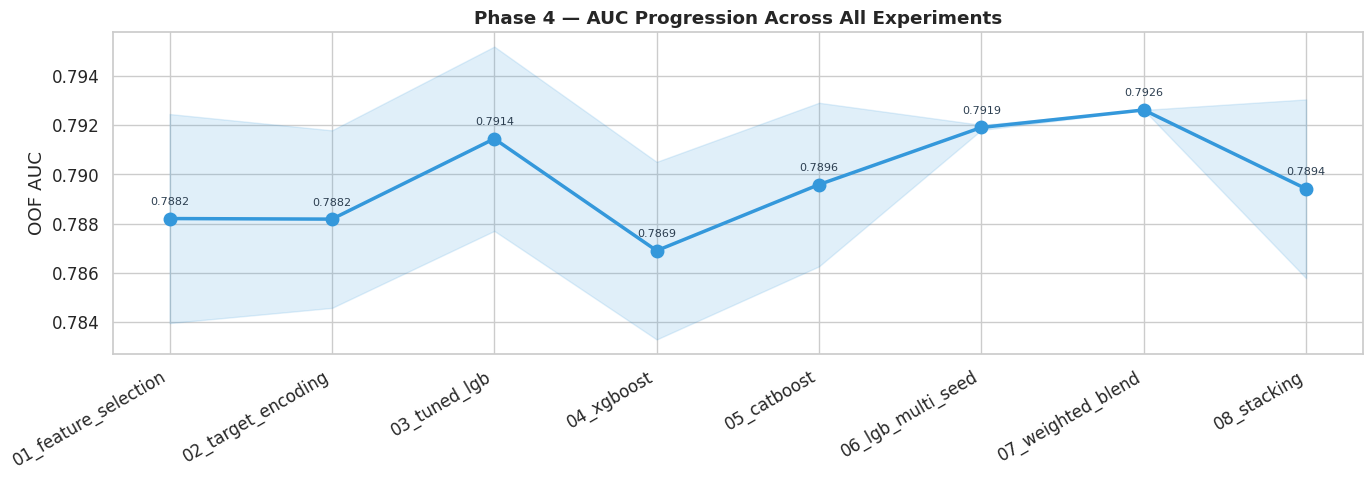

In [22]:
log_df = pd.DataFrame(EXP_LOG)

print('\n📋 Full Phase 4 Experiment Log:')
print('=' * 90)
print(log_df[['experiment','n_features','oof_auc','std_auc','delta','notes']]
      .to_string(index=False))
print('=' * 90)

# Visual AUC progression
fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(log_df))
ax.plot(x, log_df['oof_auc'], 'o-', color='#3498db', linewidth=2.5, markersize=9)
ax.fill_between(x,
                log_df['oof_auc'] - log_df['std_auc'],
                log_df['oof_auc'] + log_df['std_auc'],
                alpha=0.15, color='#3498db')

# Annotate each point
for i, (auc, name) in enumerate(zip(log_df['oof_auc'], log_df['experiment'])):
    ax.annotate(f'{auc:.4f}', (i, auc), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=8, color='#2c3e50')

ax.set_xticks(x)
ax.set_xticklabels(log_df['experiment'], rotation=30, ha='right')
ax.set_ylabel('OOF AUC')
ax.set_title('Phase 4 — AUC Progression Across All Experiments', fontweight='bold')
plt.tight_layout()
plt.show()

## 5.2 — Model Correlation Analysis

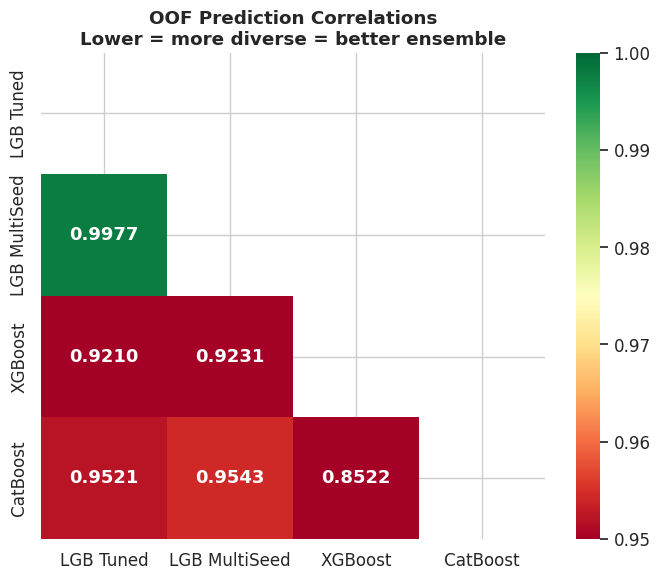

💡 Real-World Note:
   Correlations above 0.98 indicate models are too similar.
   LGB Multi-seed and LGB Tuned will be highly correlated (same algorithm).
   XGBoost and CatBoost should show lower correlation → best ensemble contributors.


In [23]:
# Low correlation between models = high diversity = better ensemble
oof_df = pd.DataFrame({
    'LGB Tuned'    : oof_tuned,
    'LGB MultiSeed': oof_lgb_multi,
    'XGBoost'      : oof_xgb,
    'CatBoost'     : oof_cb,
})

corr = oof_df.corr()

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.4f', cmap='RdYlGn',
            vmin=0.95, vmax=1.0, ax=ax, mask=mask,
            annot_kws={'size': 13, 'weight': 'bold'})
ax.set_title('OOF Prediction Correlations\n'
             'Lower = more diverse = better ensemble', fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Real-World Note:')
print('   Correlations above 0.98 indicate models are too similar.')
print('   LGB Multi-seed and LGB Tuned will be highly correlated (same algorithm).')
print('   XGBoost and CatBoost should show lower correlation → best ensemble contributors.')

## 5.3 — SHAP Values (Model Explainability)

Computing SHAP values on 5,000 sample...


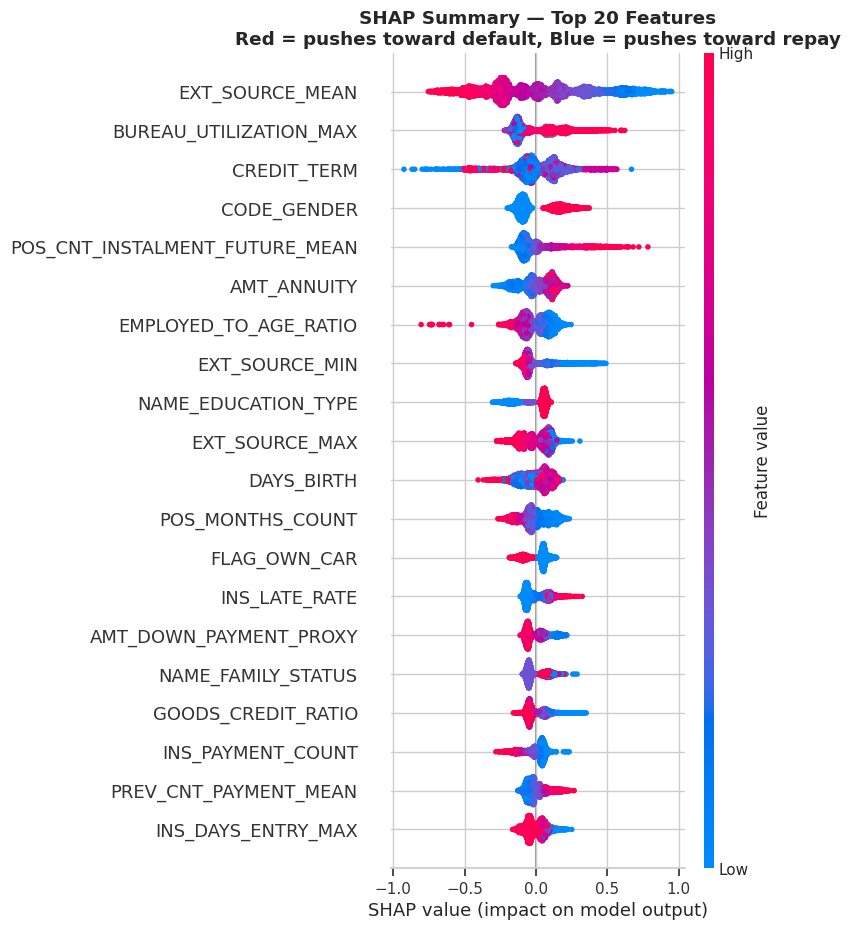


Top 15 features by SHAP importance (mean |SHAP value|):
EXT_SOURCE_MEAN                   0.317238
BUREAU_UTILIZATION_MAX            0.140886
CREDIT_TERM                       0.128711
CODE_GENDER                       0.125694
POS_CNT_INSTALMENT_FUTURE_MEAN    0.103674
AMT_ANNUITY                       0.089595
EMPLOYED_TO_AGE_RATIO             0.087919
EXT_SOURCE_MIN                    0.087846
NAME_EDUCATION_TYPE               0.086950
EXT_SOURCE_MAX                    0.084655
DAYS_BIRTH                        0.080836
POS_MONTHS_COUNT                  0.078274
FLAG_OWN_CAR                      0.070174
INS_LATE_RATE                     0.068085
AMT_DOWN_PAYMENT_PROXY            0.063421

💡 Real-World Note:
   SHAP values are the gold standard for model explainability.
   In regulated industries (banking, insurance), model explanations
   are legally required (GDPR Article 22, ECOA adverse action notices).
   Each rejected applicant must receive a reason — SHAP gives you that.


In [24]:
# SHAP values on the best LGB model
# Use a sample for speed — SHAP is O(n) in samples

try:
    import shap
    print('Computing SHAP values on 5,000 sample...')

    sample_idx = np.random.choice(len(X_sel_final), 5000, replace=False)
    X_shap     = X_sel_final.iloc[sample_idx]

    # Use the first fold's model
    explainer   = shap.TreeExplainer(models_tuned[0])
    shap_values = explainer.shap_values(X_shap)

    # For binary classification, shap_values is a list [class0, class1]
    if isinstance(shap_values, list):
        shap_vals = shap_values[1]  # Class 1 (default)
    else:
        shap_vals = shap_values

    # Summary plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_vals, X_shap, max_display=20,
                      plot_type='dot', show=False)
    plt.title('SHAP Summary — Top 20 Features\n'
              'Red = pushes toward default, Blue = pushes toward repay',
              fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Feature importance from SHAP
    shap_importance = pd.Series(
        np.abs(shap_vals).mean(axis=0),
        index=X_shap.columns
    ).sort_values(ascending=False)

    print('\nTop 15 features by SHAP importance (mean |SHAP value|):')
    print(shap_importance.head(15).to_string())

    print('\n💡 Real-World Note:')
    print('   SHAP values are the gold standard for model explainability.')
    print('   In regulated industries (banking, insurance), model explanations')
    print('   are legally required (GDPR Article 22, ECOA adverse action notices).')
    print('   Each rejected applicant must receive a reason — SHAP gives you that.')

except ImportError:
    print('SHAP not installed. Run: pip install shap')
    print('Then re-run this cell.')

## 5.4 — Calibration Check

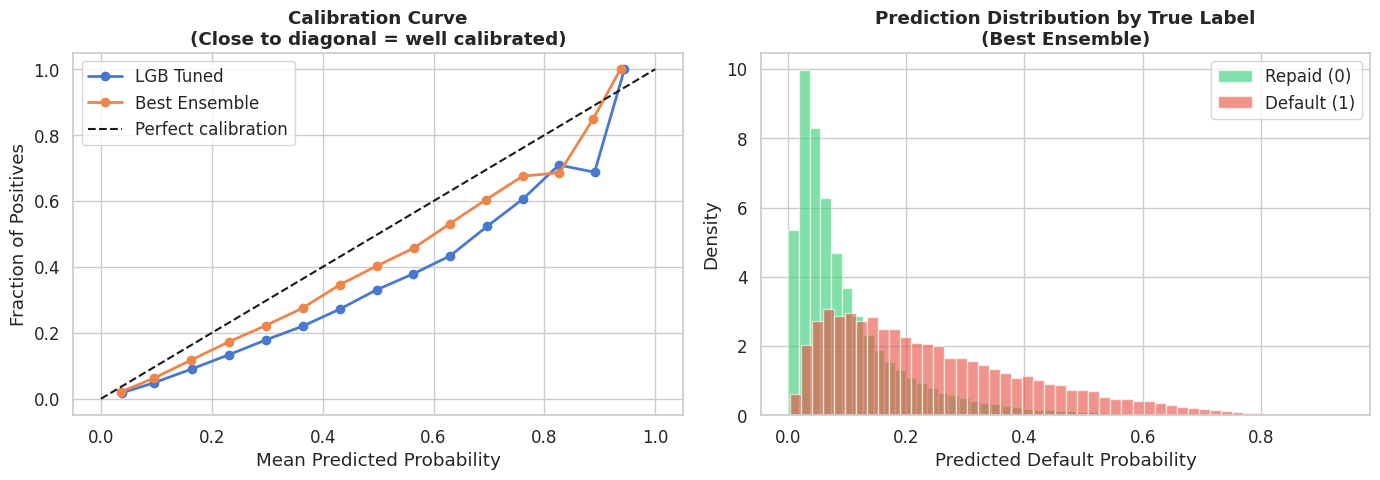

💡 Real-World Note:
   A well-calibrated model outputs probabilities that match real-world rates.
   If a model says 30% default probability, ~30% of those loans should default.
   Banks use these probabilities for:
     - Setting interest rates (higher prob → higher rate)
     - Calculating Expected Loss (PD × LGD × EAD)
     - Regulatory capital requirements (Basel III)
   If poorly calibrated → apply isotonic regression or Platt scaling.


In [25]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calibration curve
ax = axes[0]
for name, oof in [('LGB Tuned', oof_tuned), ('Best Ensemble', best_oof)]:
    frac_pos, mean_pred = calibration_curve(y, oof, n_bins=15)
    ax.plot(mean_pred, frac_pos, 'o-', label=name, linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curve\n(Close to diagonal = well calibrated)', fontweight='bold')
ax.legend()

# Prediction distribution
ax2 = axes[1]
ax2.hist(best_oof[y == 0], bins=50, alpha=0.6, color=PALETTE['repaid'],
         density=True, label='Repaid (0)')
ax2.hist(best_oof[y == 1], bins=50, alpha=0.6, color=PALETTE['default'],
         density=True, label='Default (1)')
ax2.set_xlabel('Predicted Default Probability')
ax2.set_ylabel('Density')
ax2.set_title('Prediction Distribution by True Label\n(Best Ensemble)', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

print('💡 Real-World Note:')
print('   A well-calibrated model outputs probabilities that match real-world rates.')
print('   If a model says 30% default probability, ~30% of those loans should default.')
print('   Banks use these probabilities for:')
print('     - Setting interest rates (higher prob → higher rate)')
print('     - Calculating Expected Loss (PD × LGD × EAD)')
print('     - Regulatory capital requirements (Basel III)')
print('   If poorly calibrated → apply isotonic regression or Platt scaling.')

## 5.5 — Final Submission

In [26]:
# ── Generate final submission ─────────────────────────────────────────────────
submission = pd.DataFrame({
    'SK_ID_CURR': ids_test,
    'TARGET'    : best_test_preds
})

submission.to_csv('submission_phase4_final.csv', index=False)

print('✅ Final submission saved: submission_phase4_final.csv')
print(f'   Shape                : {submission.shape}')
print(f'   Prediction range     : [{best_test_preds.min():.4f}, {best_test_preds.max():.4f}]')
print(f'   Mean prediction      : {best_test_preds.mean():.4f}')
print(f'   Best ensemble        : {best_ens_name}')
print(f'   Best OOF AUC         : {best_ens_auc:.6f}')

# Save full experiment log
log_df.to_csv('experiment_log_phase4.csv', index=False)
print(f'\n✅ Experiment log saved : experiment_log_phase4.csv')

# Final summary table
print('\n' + '=' * 60)
print('PHASE 4 FINAL SUMMARY')
print('=' * 60)
print(f'  Phase 2 Baseline AUC        : ~0.755')
print(f'  Phase 3 (all tables)        : ~0.785')
print(f'  Phase 4 — Feature selection : {log_df.loc[log_df.experiment=="01_feature_selection","oof_auc"].values[0]:.6f}')
print(f'  Phase 4 — Target encoding   : {log_df.loc[log_df.experiment=="02_target_encoding",  "oof_auc"].values[0]:.6f}')
print(f'  Phase 4 — Tuned LGB         : {log_df.loc[log_df.experiment=="03_tuned_lgb",        "oof_auc"].values[0]:.6f}')
print(f'  Phase 4 — Best Ensemble     : {best_ens_auc:.6f}')
print(f'  Total gain vs baseline      : +{best_ens_auc - 0.755:.4f}')
print('=' * 60)

✅ Final submission saved: submission_phase4_final.csv
   Shape                : (48744, 2)
   Prediction range     : [0.0023, 0.8242]
   Mean prediction      : 0.1059
   Best ensemble        : Optimized Blend
   Best OOF AUC         : 0.792610

✅ Experiment log saved : experiment_log_phase4.csv

PHASE 4 FINAL SUMMARY
  Phase 2 Baseline AUC        : ~0.755
  Phase 3 (all tables)        : ~0.785
  Phase 4 — Feature selection : 0.788201
  Phase 4 — Target encoding   : 0.788178
  Phase 4 — Tuned LGB         : 0.791441
  Phase 4 — Best Ensemble     : 0.792610
  Total gain vs baseline      : +0.0376


---
## ✅ Phase 4 Complete

### What You've Built

| Component | What it does | Real-world equivalent |
|---|---|---|
| Feature selection | Removes noise features | Model governance / feature registry |
| Target encoding | Encodes category risk rates | Weight of Evidence (WoE) scorecard |
| Optuna tuning | Finds optimal model params | MLOps hyperparameter service |
| Multi-model ensemble | Combines LGB + XGB + CatBoost | Model combination / challenger-champion |
| SHAP explainability | Explains individual predictions | Adverse action notices (ECOA/GDPR) |
| Calibration check | Verifies probability accuracy | PD model validation (Basel III) |

### What's Next (If You Want to Go Further)
- **Pseudo-labeling:** Use test predictions to augment training data
- **Neural network:** Add TabNet or MLP as a 4th ensemble member for more diversity  
- **Time-based features:** Recent bureau behavior weighted more than old behavior
- **Meta-features from Phase 3B:** Train sub-models on supplementary tables and use their predictions as features

---
> 💡 **Final Real-World Note:**  
> A credit model in production goes through: Champion/Challenger testing →
> Stress testing → Regulatory review → Approval → Gradual rollout → Monthly monitoring.
> The AUC you computed is just the beginning. Model governance, drift detection,
> and fair lending audits are where the real production work lives.